In [1]:
library(limma)
library(reshape2)
library(gridExtra)

source("../../evaluation_utils/plots/eda_plots.R")
source("../../evaluation_utils/filtering/filtering_normalization.R")
source("../../evaluation_utils/simulation/simulation_func.R")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::combine() masks gridExtra::combine()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘data.table’


The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose


The following objects are masked from ‘package:reshape2’:

    dcast, melt



Attaching packag

# Settings

In [2]:
generate_metadata <- function(batch_info, mode) {
  
  # Define scaling factors based on the mode
  mode_parts <- strsplit(mode, "_")[[1]]
  
  # Extract imbalance type and scaling factor
  if (mode_parts[1] == "balanced") {
    imbalance_type <- "balanced"
    scale_factor <- as.numeric(sub("x", "", mode_parts[2]))
  } else {
    imbalance_type <- paste(mode_parts[1], "imbalanced", sep = "_")
    scale_factor <- as.numeric(sub("x", "", mode_parts[3]))
  }
  
  # Initialize condition and batch vectors
  condition <- NULL
  batch <- NULL
  
  if (imbalance_type == "balanced") {
    # Balanced modes
    # Define total samples per group based on scale
    samples_per_group <- 33 * scale_factor
    
    # Create batch assignments equally distributed among batches
    batches <- rep(c("batch1", "batch2", "batch3"), length.out = samples_per_group)
    batches <- sample(batches)  # Shuffle batches
    
    # Assign conditions and batches
    condition <- as.factor(rep(c("A", "B"), each = samples_per_group))
    batch <- as.factor(rep(batches, 2))
    
  } else {
    if ((imbalance_type == "strong_imbalanced") & (scale_factor == 1)) {
        base_A <- c(batch1 = 9, batch2 = 3, batch3 = 31)
        base_B <- c(batch1 = 3, batch2 = 5, batch3 = 15)
    } else if (imbalance_type == "strong_imbalanced") {
        base_A <- c(batch1 = 37, batch2 = 31, batch3 = 304) * (scale_factor/10)
        base_B <- c(batch1 = 8, batch2 = 63, batch3 = 217) * (scale_factor/10)
    }  else {
        stop("Invalid imbalance type specified.")
    }
    
    # # Scale the base counts
    # scaled_A <- base_A * scale_factor
    # scaled_B <- base_B * scale_factor
    scaled_A <- base_A
    scaled_B <- base_B
    
    # Ensure counts are integers
    scaled_A <- round(scaled_A)
    scaled_B <- round(scaled_B)
    
    # Create batch assignments for each group
    batches_A <- rep(names(scaled_A), times = scaled_A)
    batches_B <- rep(names(scaled_B), times = scaled_B)
    
    # Shuffle batch assignments
    batches_A <- sample(batches_A)
    batches_B <- sample(batches_B)
    
    # Assign conditions and batches
    condition <- as.factor(c(rep("A", length(batches_A)), rep("B", length(batches_B))))
    batch <- as.factor(c(batches_A, batches_B))
  }
  
  # Update the batch_info dataframe
  batch_info$condition <- condition
  batch_info$batch <- batch
  
  return(batch_info)
}


In [3]:
workdir <- "/home/yuliya/repos/cosybio/FedProt/data/simulated_scaled/"

number_of_runs = 10

mu_1 = 1.25
mu_4 = 1.25

frac_1 = 0.04
frac_7 = 0.15


## generate data

In [4]:
check_dirs <- function(workdir){
    if (!dir.exists(workdir)){
        dir.create(workdir)
    }
}

[1] "Number of samples: 6600"
[1] "Mode: balanced with scaling factor: 100x. Batch info shape: 6600"
[2] "Mode: balanced with scaling factor: 100x. Batch info shape: 1"   


`summarise()` has grouped output by 'batch'. You can override using the
`.groups` argument.


# A tibble: 6 × 3
# Groups:   batch [3]
  batch  condition     n
  <fct>  <fct>     <int>
1 batch1 A          1100
2 batch1 B          1100
3 batch2 A          1100
4 batch2 B          1100
5 batch3 A          1100
6 batch3 B          1100
0.5 
0.5[1] "Mode: balanced with scaling factor: 100x"
[1] "Run number 1"
1980 
Number of DE proteins:  350 
  Number of proteins:  6000 


Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count


% of missing values: 20.06



[1] "Run number 2"
1980 
Number of DE proteins:  350 
  Number of proteins:  6000 


% of missing values: 20.07



[1] "Run number 3"
1980 
Number of DE proteins:  350 
  Number of proteins:  6000 


% of missing values: 20.06



[1] "Run number 4"
1980 
Number of DE proteins:  350 
  Number of proteins:  6000 


Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(lab)

  # Now:
  data %>% select(all_of(lab))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


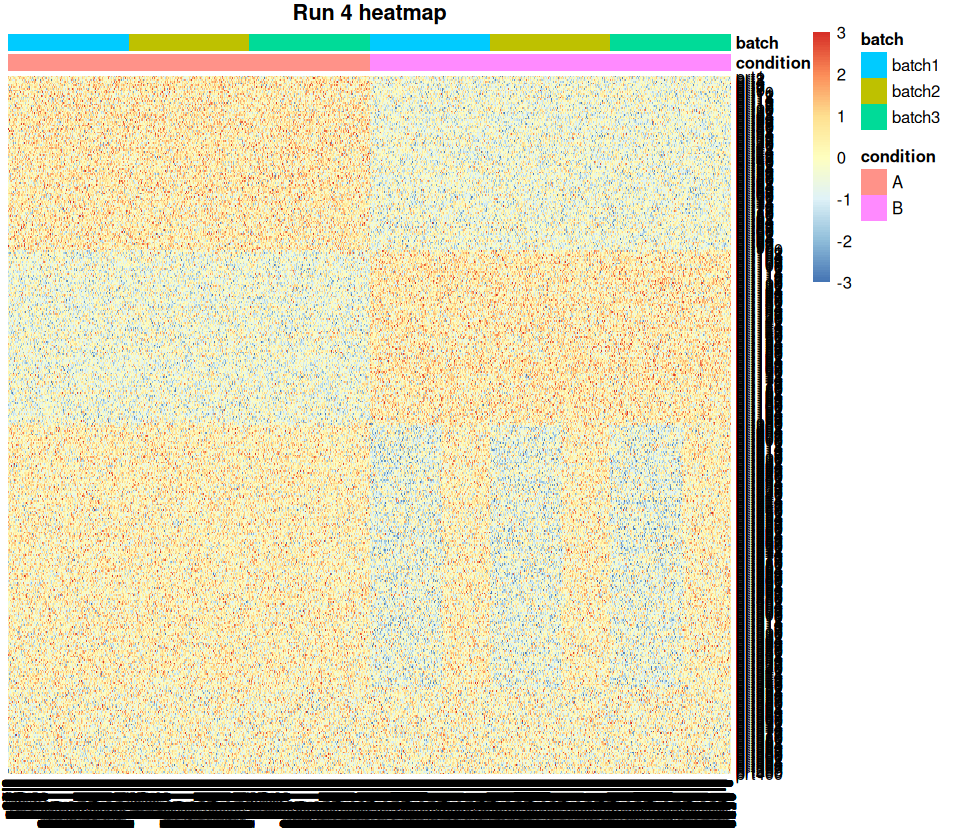

% of missing values: 20.06



[1] "Run number 5"
1980 
Number of DE proteins:  350 
  Number of proteins:  6000 


% of missing values: 20.07



[1] "Run number 6"
1980 
Number of DE proteins:  350 
  Number of proteins:  6000 


% of missing values: 20.07



[1] "Run number 7"
1980 
Number of DE proteins:  350 
  Number of proteins:  6000 


% of missing values: 20.06



[1] "Run number 8"
1980 
Number of DE proteins:  350 
  Number of proteins:  6000 


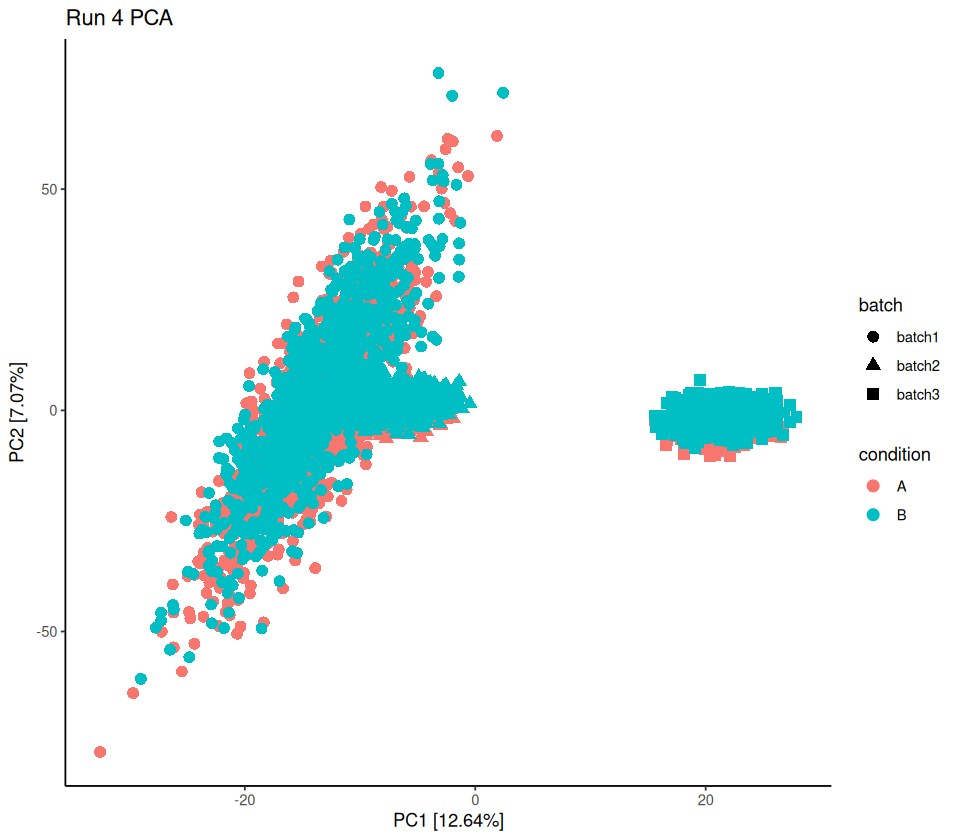

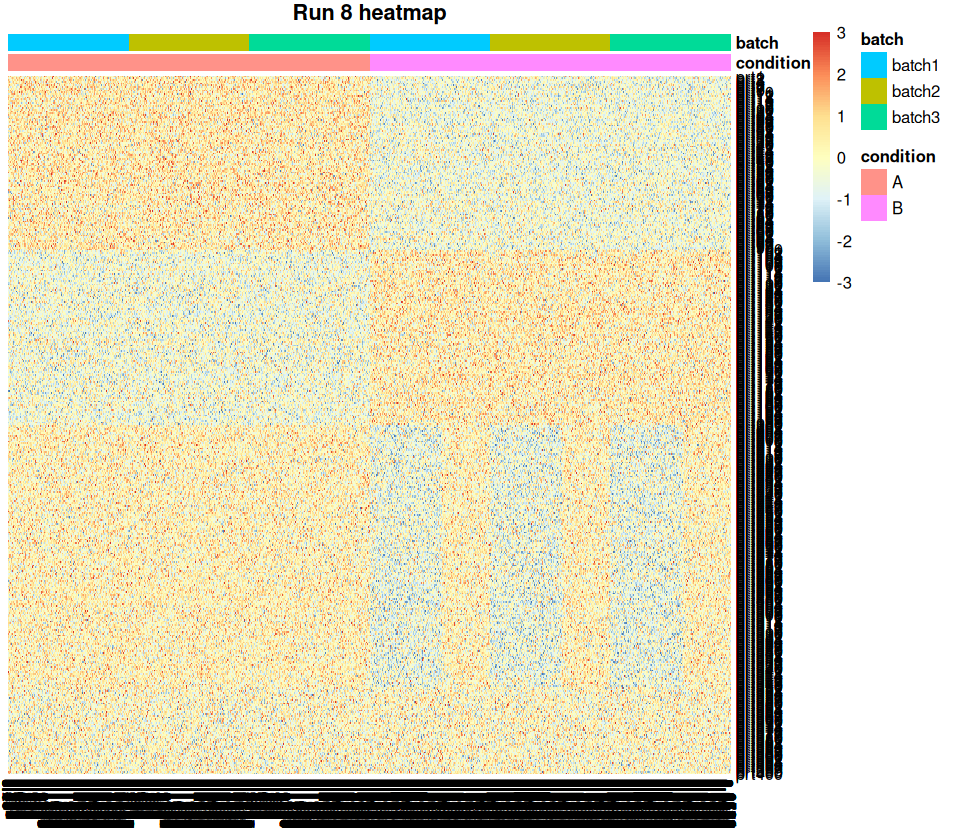

% of missing values: 20.07



[1] "Run number 9"
1980 
Number of DE proteins:  350 
  Number of proteins:  6000 


% of missing values: 20.07



[1] "Run number 10"
1980 
Number of DE proteins:  350 
  Number of proteins:  6000 


% of missing values: 20.06



...

[1] "Run number 2"
1850 
Number of DE proteins:  350 
  Number of proteins:  6000 


% of missing values: 20.06



[1] "Run number 3"
1850 
Number of DE proteins:  350 
  Number of proteins:  6000 


% of missing values: 20.06



[1] "Run number 4"
1850 
Number of DE proteins:  350 
  Number of proteins:  6000 


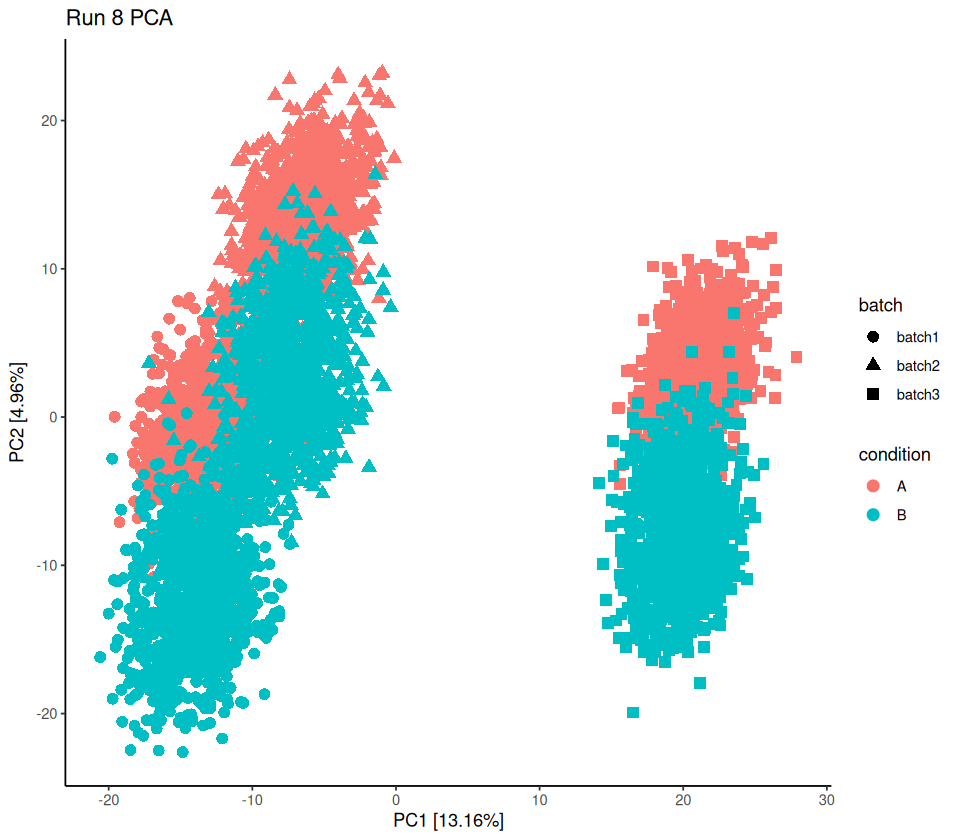

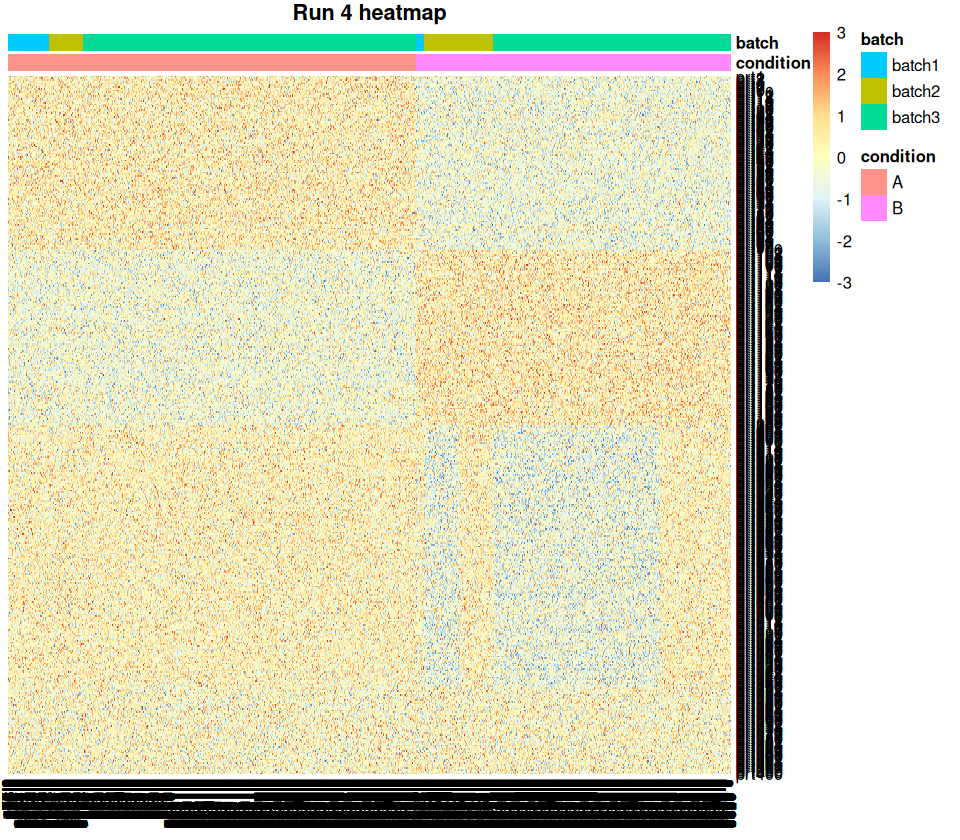

% of missing values: 20.06



[1] "Run number 5"
1850 
Number of DE proteins:  350 
  Number of proteins:  6000 


% of missing values: 20.07



[1] "Run number 6"
1850 
Number of DE proteins:  350 
  Number of proteins:  6000 


% of missing values: 20.06



[1] "Run number 7"
1850 
Number of DE proteins:  350 
  Number of proteins:  6000 


% of missing values: 20.06



[1] "Run number 8"
1850 
Number of DE proteins:  350 
  Number of proteins:  6000 


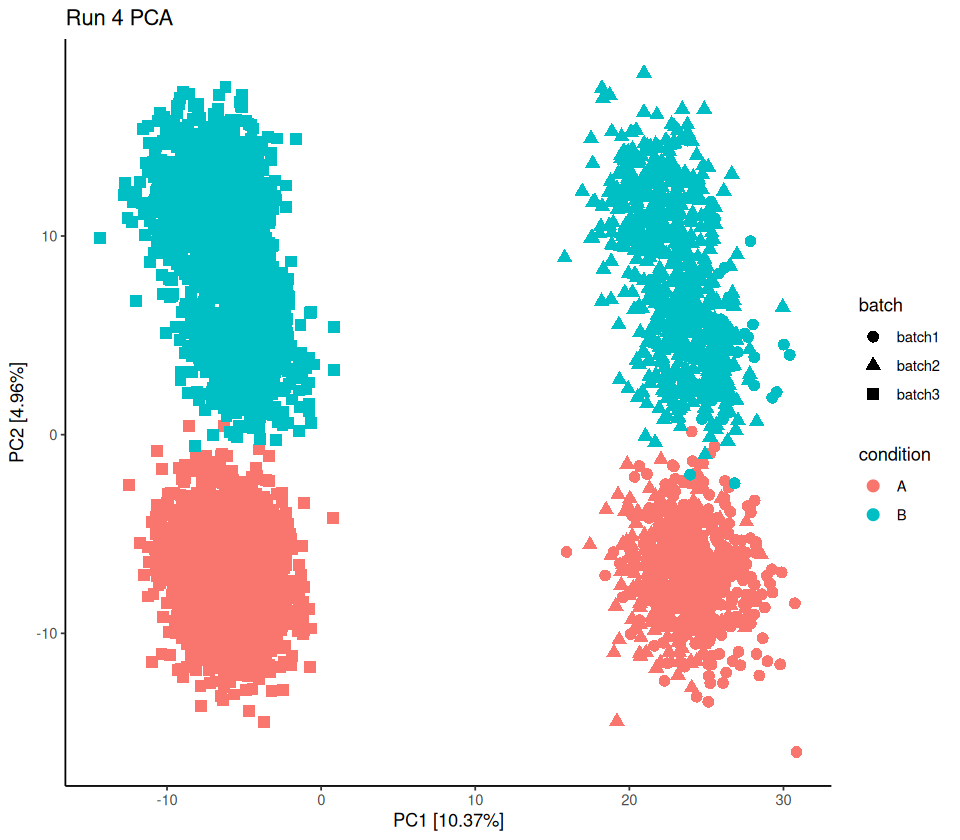

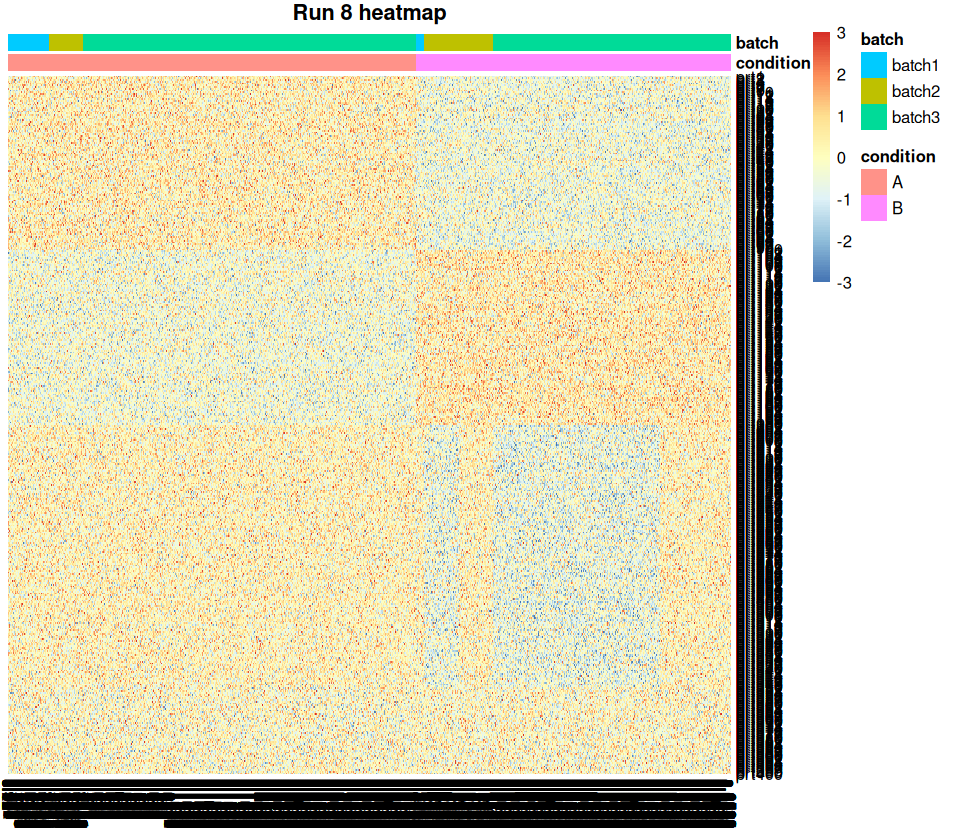

% of missing values: 20.06



[1] "Run number 9"
1850 
Number of DE proteins:  350 
  Number of proteins:  6000 


% of missing values: 20.06



[1] "Run number 10"
1850 
Number of DE proteins:  350 
  Number of proteins:  6000 


% of missing values: 20.07



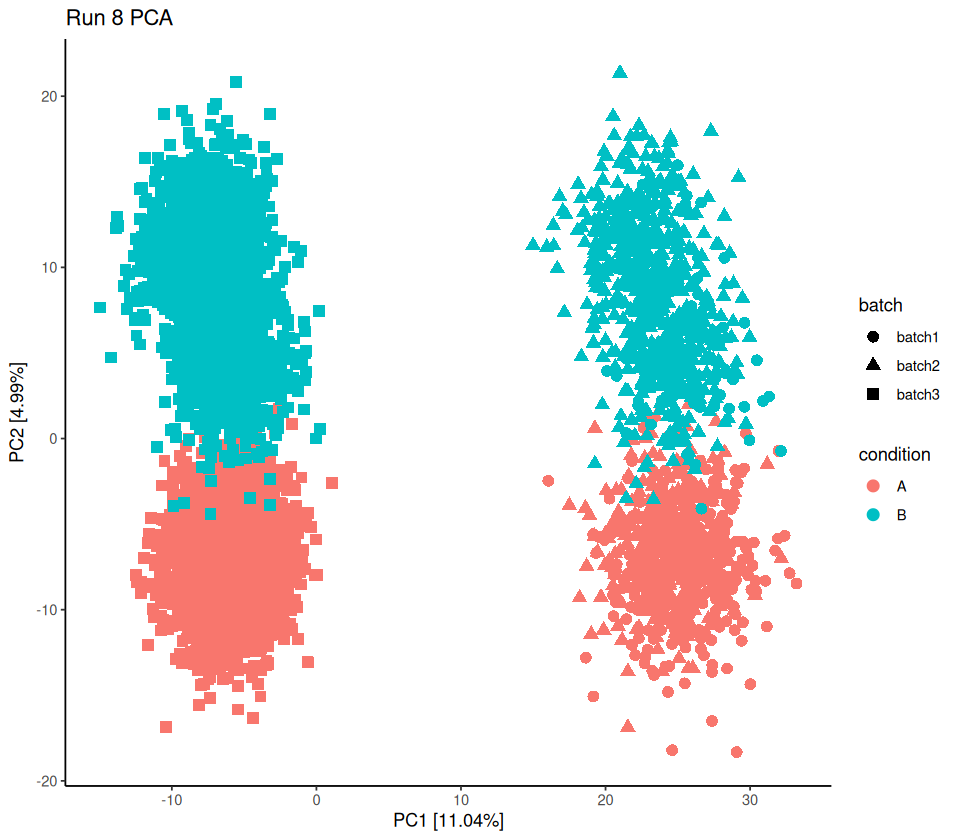

In [5]:
for (mode in c(
    # "balanced_1x", "balanced_10x", 
    "balanced_100x",
    # "strong_imbalanced_1x", "strong_imbalanced_10x", 
    "strong_imbalanced_100x"
)){ 
    sub_path = mode
    mode_parts <- strsplit(mode, "_")[[1]]
    if (mode_parts[1] == "balanced") {
        mode_name <- "balanced"
        scaling_factor <- mode_parts[2]
    } else {
        mode_name <- paste(mode_parts[1], "imbalanced", sep = "_")
        scaling_factor <- mode_parts[3]
    }

    # Set directories
    generated_data_directory <- paste0(workdir, sub_path, "/data")
    check_dirs(generated_data_directory)

    # number of samples
    m = 66 * as.numeric(sub("x", "", scaling_factor))

    # Create metadata
    batch_info <- data.frame(file = paste("s", 1:m, sep="."))
    print(paste0("Number of samples: ", m))
    print(paste0("Mode: ", mode_name, " with scaling factor: ", scaling_factor, ". Batch info shape: ", dim(batch_info)))
    rownames(batch_info) <- batch_info$file
    batch_info <- generate_metadata(batch_info, mode)
    batch_info %>% group_by(batch, condition) %>%
        summarise(n = n()) %>% print()
    
    # Set parameters for simulation
    col_frac_A = length(batch_info[batch_info$condition == "A",]$file) / m
    col_frac_B = length(batch_info[batch_info$condition == "B",]$file) / m
    cat(col_frac_A, "\n")
    cat(col_frac_B)

    print(paste0("Mode: ", mode_name, " with scaling factor: ", scaling_factor))
    # Run simulation
    for(j in 1:number_of_runs){
        i = 1  
        print(paste0("Run number ", j))
        set.seed(runif(1, 1, 10000))

        result <- generate_data(
            col_frac_A, col_frac_B,
            frac_1, frac_7,
            mu_1=mu_1, mu_4=mu_4,
            batch_info=batch_info,
            mode_version = mode_name,
            m = m
        ) %>% as.data.frame()
        
        number_DE <- frac_1*2500*2 + frac_7*1000

        rownames(result) <- c(paste0("prt", 1:length(rownames(result))))
        dim(result)
        cat("Number of DE proteins: ", number_DE, "\n", " Number of proteins: ", nrow(result), "\n")

        # second, add batch effects
        data_with_batch_effects <- add_batch_effect(result, batch_info)

        if (j %% 4 == 0){
            # plots here
            # reorder batch_info first by condition, then by batch inside condition
            batch_info_plot <- batch_info[order(batch_info$condition, batch_info$batch),]
            # z-transform the data
            result_z <- t(scale(t(result[, batch_info_plot$file])))

            options(repr.plot.width=7, repr.plot.height=5)
            heatmap_nocor_plot(
                result_z[1:(number_DE+50),], batch_info_plot, paste0("Run ", j),
                condition="condition", lab="batch",
                use_breaks = TRUE)

            # reorder batch_info first by condition, then by batch inside condition
            options(repr.plot.width=8, repr.plot.height=7)
            pca_plotted <- pca_plot(data_with_batch_effects[, batch_info$file][1:number_DE,], batch_info, 
                title=paste0(paste0("Run ", j), " PCA"),
                quantitative_col_name='file',
                col_col='condition', shape_col='batch'
            )
            print(pca_plotted)
            # Remove plot objects if necessary
            rm(result_z, batch_info_plot, pca_plotted)
        }
        # Remove large intermediate objects
        rm(result)

        # Add missing values
        data_with_batch_effects_missing <- simulateMissingValues(data_with_batch_effects, alpha = 0.2, beta = 0.5)
        n_na <- sum(is.na(data_with_batch_effects_missing)) / (nrow(data_with_batch_effects_missing) * ncol(data_with_batch_effects_missing))
        message((paste0("% of missing values: ", round(n_na*100, 2))))
        if (mode %in% c("balanced_1x", "strong_imbalanced_1x")){
            data_with_batch_effects_missing <- fix_missing(data_with_batch_effects_missing, data_with_batch_effects, batch_info)
            n_na <- sum(is.na(data_with_batch_effects_missing)) / (nrow(data_with_batch_effects_missing) * ncol(data_with_batch_effects_missing))
            message((paste0("% of missing values: ", round(n_na*100, 2))))
        }
        # Remove large intermediate objects
        rm(data_with_batch_effects)

        #write data for each lab
        write.table(data_with_batch_effects_missing[, batch_info[batch_info$batch == "batch1",]$file], 
                    paste0(generated_data_directory, "/",  j, "_lab_1_intensities_data.tsv"), sep = "\t")
        write.table(data_with_batch_effects_missing[, batch_info[batch_info$batch == "batch2",]$file],
                    paste0(generated_data_directory, "/",  j, "_lab_2_intensities_data.tsv"), sep = "\t")
        write.table(data_with_batch_effects_missing[, batch_info[batch_info$batch == "batch3",]$file],
                    paste0(generated_data_directory, "/",  j, "_lab_3_intensities_data.tsv"), sep = "\t")

        # Remove large intermediate objects
        rm(data_with_batch_effects_missing)
        gc(verbose = FALSE)

    }
    # write batch info
    write.table(batch_info, paste0(generated_data_directory, "/batch_info.tsv"), sep = "\t")
}

In [6]:
# all versions of all used packages print
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 24.04.1 LTS

Matrix products: default
BLAS/LAPACK: /home/yuliya/miniforge3/envs/FedProt/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Berlin
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] matrixStats_1.5.0 RobNorm_0.1.0     invgamma_1.1      foreach_1.5.2    
 [5] data.table_1.16.4 patchwork_1.3.0   lubridate_1.9.4   forcats_1.0.0    
 [9] stringr_1.5.1     dplyr_1.1.4       purrr_1.0.2   